# File showing the steps for generating the used figures and tables
## This is part of a master thesis by Mohamed Shaker

This file is also accessible on [Github](https://github.com/sherifix/my_thesis/blob/master/figures_tables_generator.ipynb) repository for reproducibility.


In [90]:
#All reuired imports

import os
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
from Bio import AlignIO, SeqIO
from collections import OrderedDict
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.patches import Circle
import re
import requests

In [91]:
'''
Print table of different GH subfamilies with member enzymes details
excluding duplicate proteins and using families with > 10 sequneces
'''

#read files downloaded from CAZy characterized pages
dir_path = 'data/raw/'
csv_files = glob.glob(os.path.join(dir_path, 'GH*.csv'))

data = []

for file in csv_files:
    gh_family = os.path.basename(file).replace('.csv', '')
    df = pd.read_csv(file)
    
    # Remove duplicate rows (same protein + same EC)
    df = df.drop_duplicates(subset=['GenBank_accession', 'EC_number'])
    
    # Remove rows with NaN accessions
    df = df.dropna(subset=['GenBank_accession'])
    
    # count total unique proteins in this family
    total_proteins = df['GenBank_accession'].nunique()
    
    #Skip families with less than 10 proteins
    if total_proteins < 10:
        continue
    
    # Count unique proteins per EC
    ec_counts = {}
    for ec in ['3.2.1.4', '3.2.1.91', '3.2.1.176']:
        ec_counts[ec] = df[df['EC_number'] == ec]['GenBank_accession'].nunique()
    
    row = {'GH (sub)family': gh_family, 'No. of Proteins': total_proteins}
    for ec in ['3.2.1.4', '3.2.1.91', '3.2.1.176']:
        row[ec] = ec_counts[ec] if ec_counts[ec] > 0 else '-'
    
    data.append(row)

df_result = pd.DataFrame(data)
df_result = df_result.rename(columns={
    '3.2.1.4': 'Endoglucanase 3.2.1.4',
    '3.2.1.91': 'Exoglucanase 3.2.1.91',
    '3.2.1.176': 'Cellobiohydrolase 3.2.1.176'
})


df_result.to_csv("./figures_tables/GH_enzyme_member.tsv", sep='\t', index=False)

print(df_result.to_csv(sep='\t', index=False))

GH (sub)family	No. of Proteins	Endoglucanase 3.2.1.4	Exoglucanase 3.2.1.91	Cellobiohydrolase 3.2.1.176
GH5_5	53	53	-	-
GH48	23	4	2	17
GH9	133	127	6	-
GH12	71	71	-	-
GH7	76	24	-	52
GH5_1	34	34	-	-
GH6	65	14	51	-
GH5_25	11	11	-	-
GH44	11	11	-	-
GH5_2	103	103	-	-
GH5_4	47	47	-	-
GH45	74	74	-	-



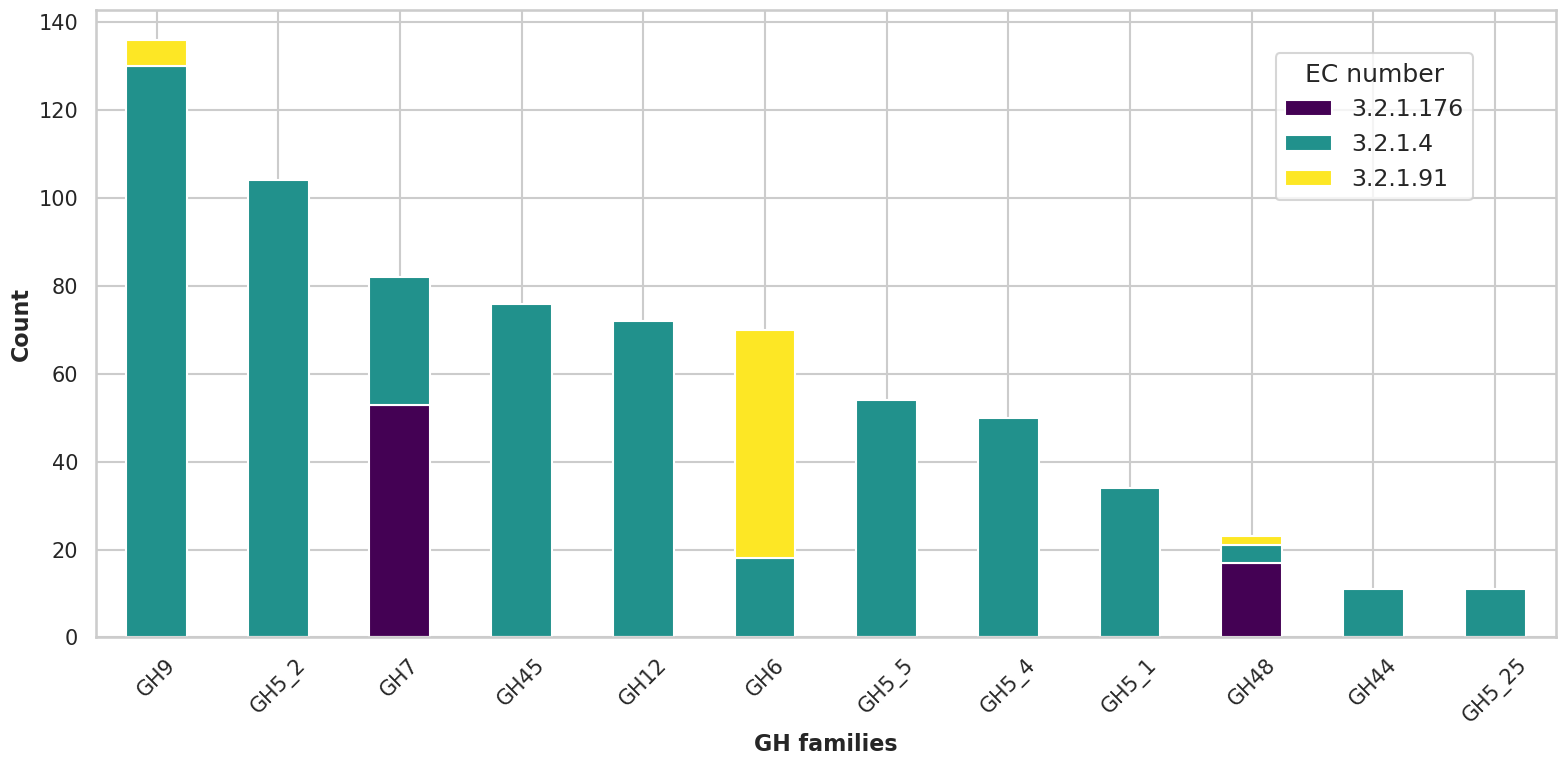

In [92]:
'''
Stacked bar for visualization of distribution of EC enzymes
in each GH (sub)family
'''


# read files
dir_path = 'data/raw/'
csv_files = glob.glob(os.path.join(dir_path, 'GH*.csv'))


data_list = []
for file in csv_files:
    gh_family = os.path.basename(file).replace('.csv', '')
    df = pd.read_csv(file)
    vc = df['EC_number'].value_counts().reset_index()
    vc.columns = ['EC_number', 'count']
    vc['GH_family'] = gh_family
    data_list.append(vc)

summary_df = pd.concat(data_list, ignore_index=True)

#calculate nfrequency per family and exclude families with less than 10 sequences

family_totals = summary_df.groupby('GH_family')['count'].sum()
valid_families = family_totals[family_totals > 10].index

filtered_df = summary_df[summary_df['GH_family'].isin(valid_families)]


#create plot
stack_df = filtered_df.pivot_table(
    index='GH_family',
    columns='EC_number',
    values='count',
    aggfunc='sum',
    fill_value=0
)

stack_df = stack_df.loc[stack_df.sum(axis=1).sort_values(ascending=False).index]

ax = stack_df.plot(kind='bar', stacked=True, figsize=(16, 8), colormap='viridis')
ax.set_ylabel('Count', fontsize=16, fontweight="bold")
ax.set_xlabel('GH families', fontsize=16, fontweight='bold')
ax.legend(title='EC number', bbox_to_anchor=(0.8, 0.95), loc='upper left', fontsize=17)
plt.xticks(rotation=45, fontsize=15)
plt.yticks(fontsize=15)
plt.savefig(os.path.join('figures_tables/', 'stackedbar_ec_numbers'), dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

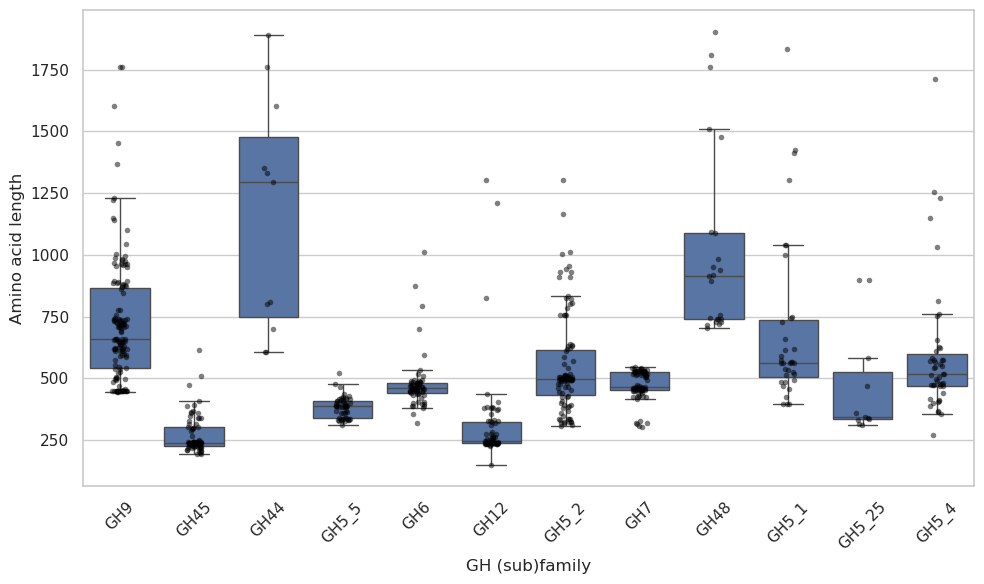

In [93]:
# Extract length of GH families 

def extract_lengths(file_path):
    if not os.path.exists(file_path):
        return pd.DataFrame()
    headers = []
    lengths = []
    current_seq = ''
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if current_seq:
                    lengths.append(len(current_seq))
                headers.append(line[1:])
                current_seq = ''
            else:
                current_seq += line
        if current_seq:
            lengths.append(len(current_seq))
    return pd.DataFrame({'header': headers, 'length': lengths})

dir_path = 'data/GH_families/'
files = glob.glob(os.path.join(dir_path, 'GH*.faa'))



all_data = []
for f in files:
    if 'domains' not in f:
        gh_family = os.path.basename(f).replace('.faa', '')
        full_df = extract_lengths(f)
        if not full_df.empty:
            full_df['GH_family'] = gh_family
            all_data.append(full_df)
           

if all_data:
    full_df = pd.concat(all_data, ignore_index=True)
    
else:
    print("No FASTA files found")

#create figure with extracted lengths data
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.boxplot(data=full_df, x='GH_family', y='length', showfliers=False)
sns.stripplot(data=full_df, x='GH_family', y='length', color='black', alpha=0.5, size=4)
plt.xticks(rotation=45)
plt.ylabel('Amino acid length')
plt.xlabel('GH (sub)family')
plt.tight_layout()
plt.savefig('figures_tables//length_aa_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [94]:
# extract length of catatlytic domain only fasta file


dir_path = 'data/domains/'
files = glob.glob(os.path.join(dir_path, 'GH*.faa'))

print(f"Found {len(files)} files")

all_data = []

for f in files:
    if 'domains' in f:
        gh_family = os.path.basename(f).replace('.faa', '')
        domain_df = extract_lengths(f)
        if not domain_df.empty:
            domain_df['GH_family'] = gh_family
            all_data.append(domain_df)
            print(f"{gh_family}: avg len {domain_df['length'].mean():.0f}")

if all_data:
    domain_df = pd.concat(all_data, ignore_index=True)
    
else:
    print("No FASTA files found")

Found 12 files
GH48_domains: avg len 559
GH7_domains: avg len 410
GH9_domains: avg len 440
GH5_1_domains: avg len 335
GH44_domains: avg len 513
GH5_5_domains: avg len 284
GH5_4_domains: avg len 281
GH45_domains: avg len 203
GH5_25_domains: avg len 286
GH5_2_domains: avg len 243
GH12_domains: avg len 154
GH6_domains: avg len 307


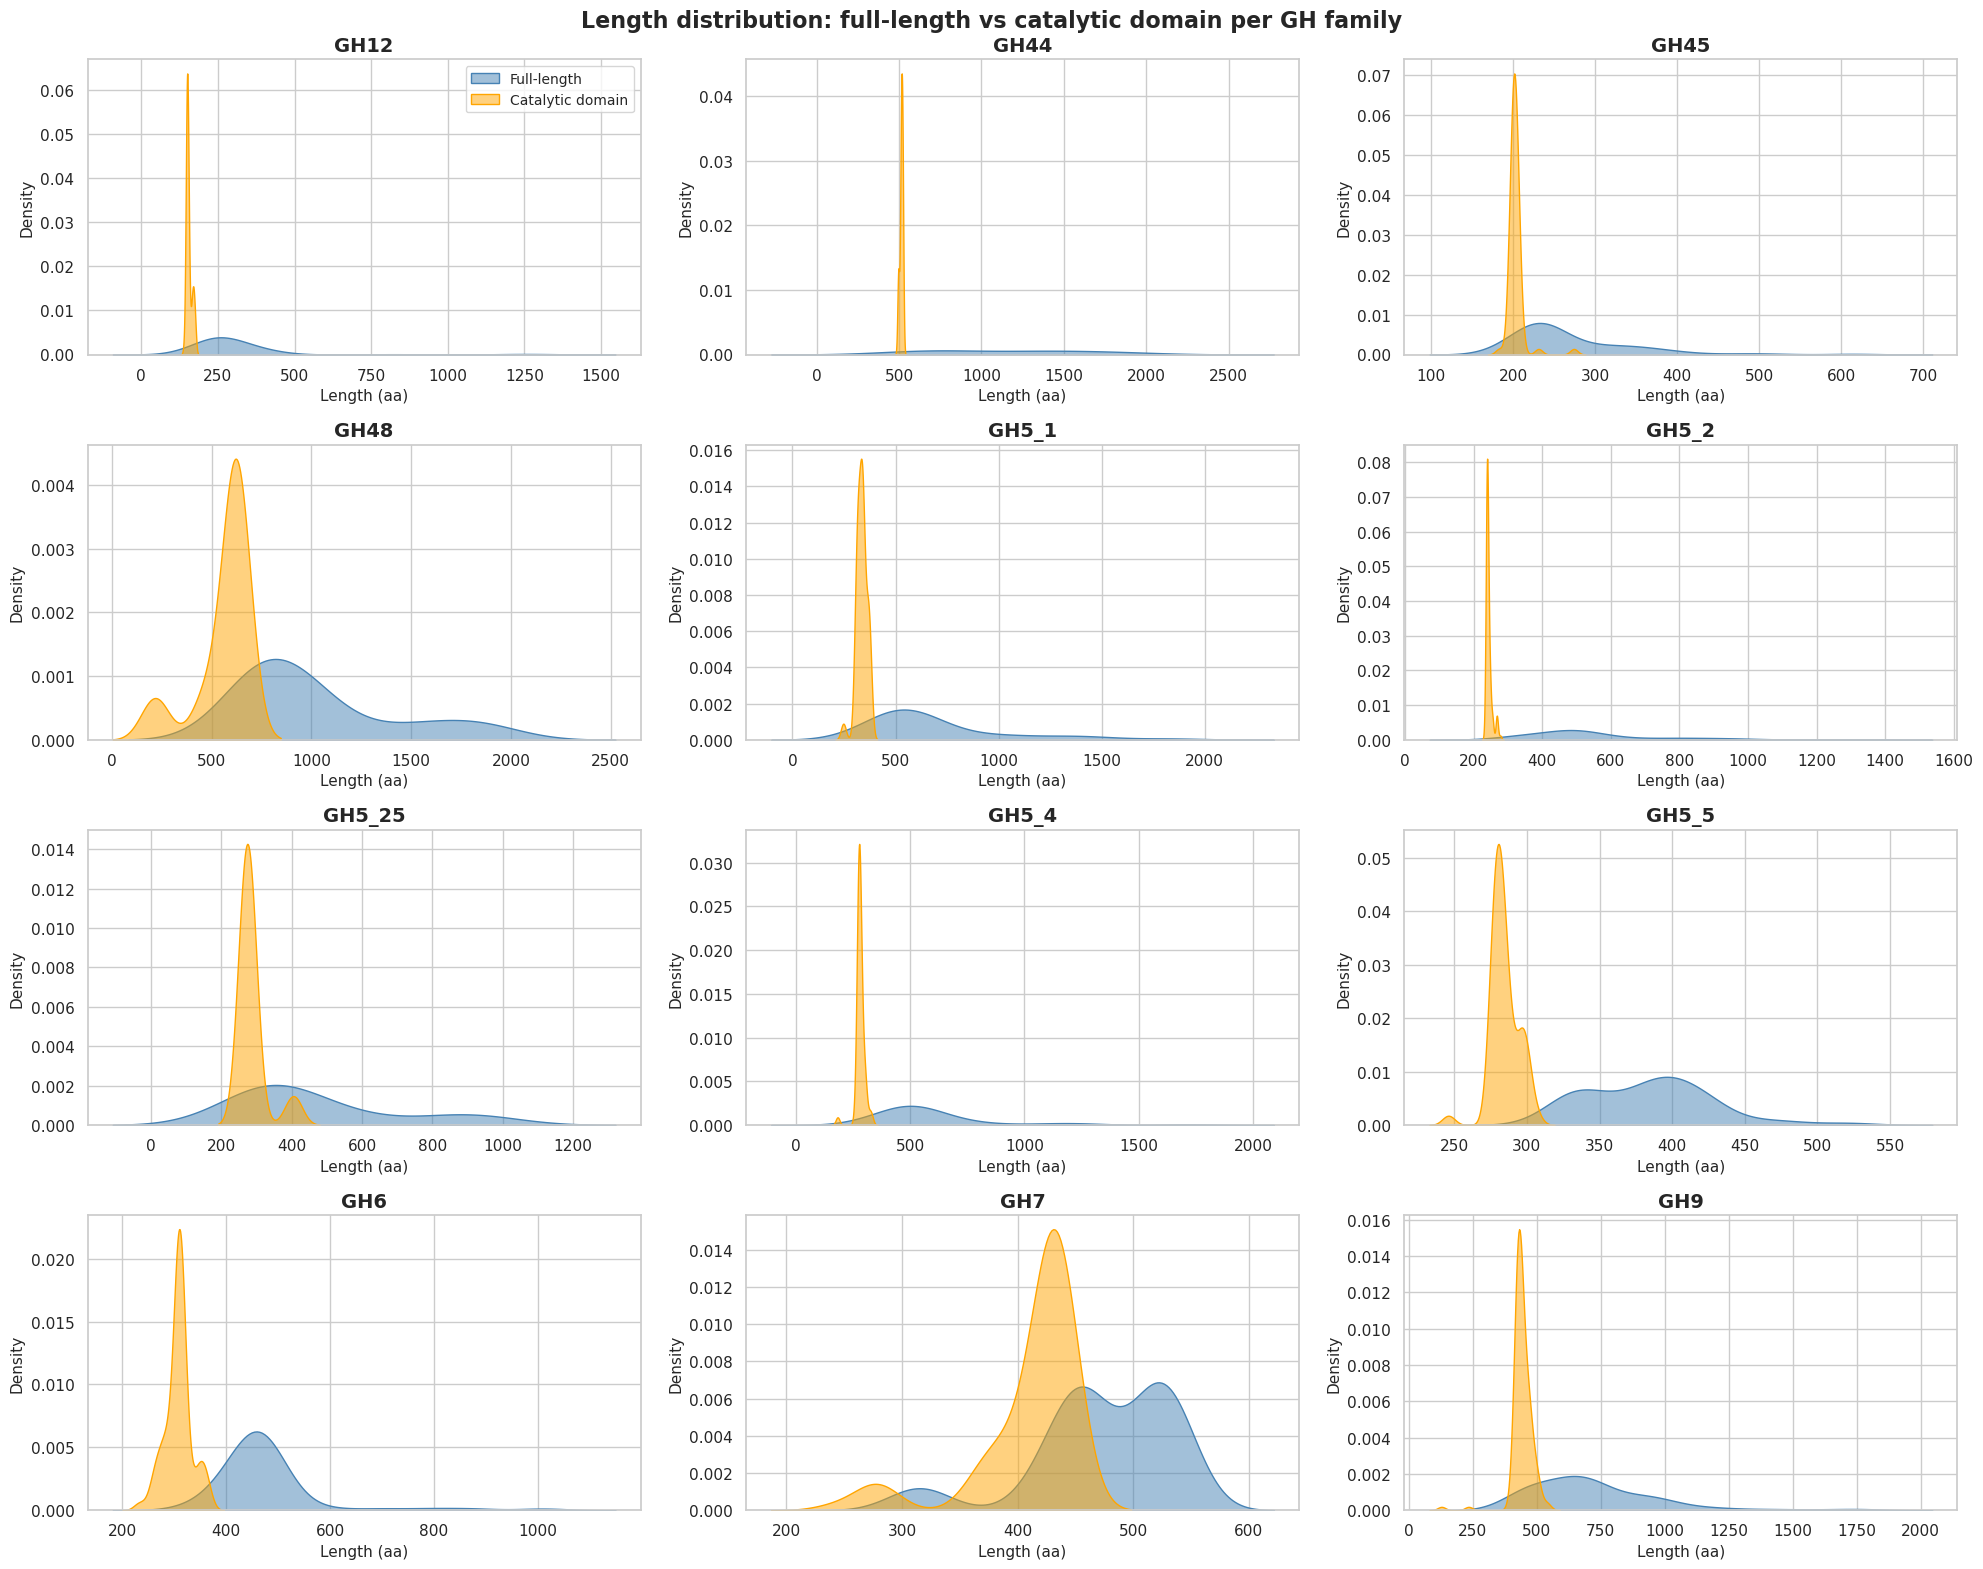

In [95]:
'''
Kernel distribution estimate illustrating the variation
in length between full-length protein and catalytic domain
'''


families = sorted(full_df['GH_family'].unique())
n = len(families)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 4))
axes = axes.flatten()

for i, gh in enumerate(families):
    ax = axes[i]

    full_sub = full_df[full_df['GH_family'] == gh]['length'].values

    # Match domain_df naming: 'GH5' → 'GH5_domains'
    domain_name = gh + '_domains'
    domain_sub = domain_df[domain_df['GH_family'] == domain_name]['length'].values

    if len(full_sub) > 1:
        sns.kdeplot(full_sub, ax=ax, fill=True, alpha=0.5,
                    color='steelblue', label='Full-length')
    if len(domain_sub) > 1:
        sns.kdeplot(domain_sub, ax=ax, fill=True, alpha=0.5,
                    color='orange', label='Catalytic domain')

    ax.set_title(gh, fontsize=14, fontweight='bold')
    ax.set_xlabel('Length (aa)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    if i == 0:
        ax.legend(fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Length distribution: full-length vs catalytic domain per GH family',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('figures_tables/supplementary_data/kde_per_family.png', dpi=300, bbox_inches='tight')
plt.show()

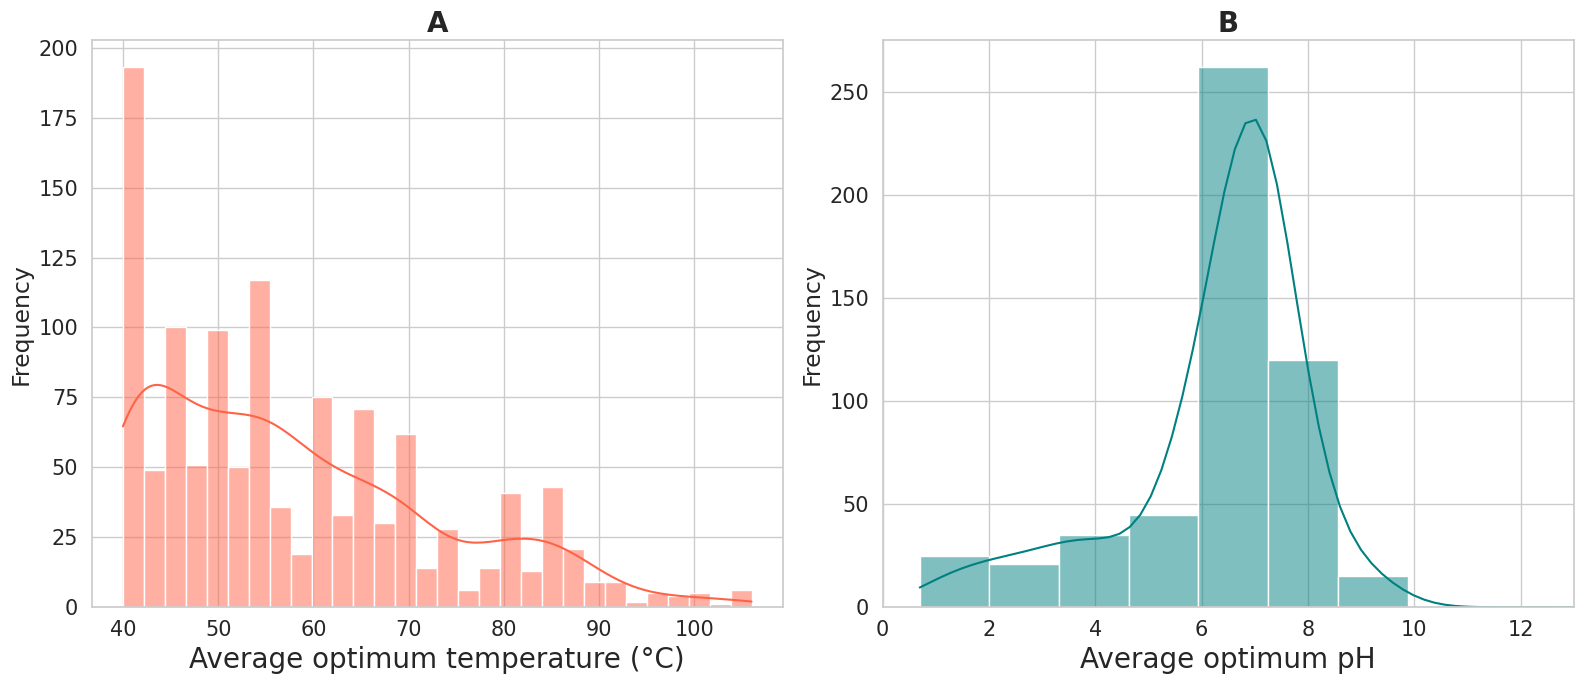

In [96]:
# ThermoBase Figures


df = pd.read_csv('data/thermobase_data/ThermoBase.csv')

df.columns = df.columns.str.strip()

# Convert numeric columns
df["Avg. Optimum Temp."] = pd.to_numeric(df["Avg. Optimum Temp."], errors="coerce")
df["Avg. Optimum pH"] = pd.to_numeric(df["Avg. Optimum pH"], errors="coerce")

# Style
sns.set(style="whitegrid", font_scale=1.0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))


# A. Average optimum temperature distribution
sns.histplot(
    df["Avg. Optimum Temp."].dropna(),
    bins=30,
    kde=True,
    ax=axes[0],
    color="tomato"
)
axes[0].set_title("A", fontsize=20, fontweight='bold')
axes[0].set_xlabel("Average optimum temperature (°C)", fontsize=20)
axes[0].set_ylabel("Frequency", fontsize=17)
axes[0].tick_params(axis='both', labelsize=15)

# B. Average optimum pH distribution
sns.histplot(
    df["Avg. Optimum pH"].dropna(),
    bins=30,
    kde=True,
    ax=axes[1],
    color="teal"
)
axes[1].set_title("B", fontsize=20, fontweight='bold')
axes[1].set_xlabel("Average optimum pH", fontsize=20)
axes[1].set_ylabel("Frequency", fontsize=17)
axes[1].set_xlim(0, 13)
axes[1].tick_params(axis='both', labelsize=15)

plt.tight_layout()
plt.savefig("figures_tables//thermobase_overview_figure.png", dpi=300, bbox_inches="tight")

plt.show()

In [97]:
# Count clusters and prepare table 

def count_clusters(file_path):
    if not os.path.exists(file_path):
        return 0
    count = 0
    with open(file_path, 'r') as f:
        for line in f:
            if '>Cluster' in line:
                count += 1
    return count

dir_path = 'data/clustered/'
files = glob.glob(os.path.join(dir_path, '*.clstr'))    

data = []
for f in files:
    gh_family = os.path.basename(f).replace('.faa.clstr', '').replace('_clustered', '')
    num_clstr = count_clusters(f)
        
    row = {'GH (sub)family': gh_family, 'No. Clusters': num_clstr}
    data.append(row)

df_clstr = pd.DataFrame(data)

df_clstr.to_csv("figures_tables/number_of_clusters.tsv", sep='\t', index=False)
print(df_clstr.to_csv(sep='\t', index=False))

GH (sub)family	No. Clusters
GH9	89
GH12	48
GH5_5	40
GH5_4	38
GH48	18
GH7	43
GH5_2	47
GH44	8
GH45	42
GH5_25	10
GH6	48
GH5_1	20



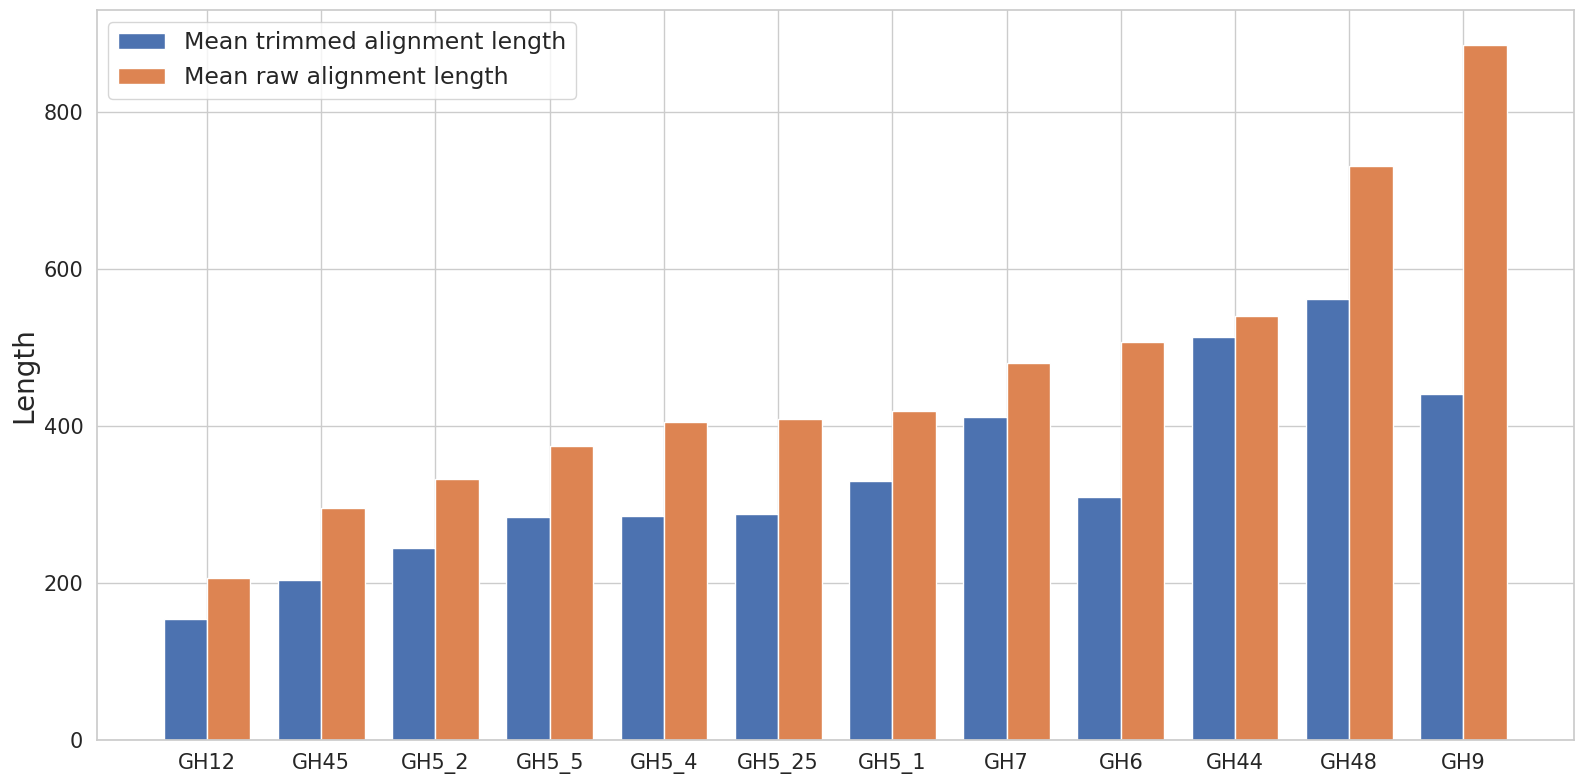

Main figure saved to: figures_tables/msa_alignment_main_figure.png


In [98]:
# Generate figure to visualize trimming alignment for all families


ALG_DIR = Path("data/alignments/")
CLSTR_DIR = Path("data/clustered/")
FIG_DIR = Path("figures_tables/")

FIG_DIR.mkdir(parents=True, exist_ok=True)



def collect_family_files(clstr_dir, alg_dir):
    clustered_files = {}
    for p in clstr_dir.glob("GH*_clustered.faa"):
        family = p.name.replace("_clustered.faa", "")
        clustered_files[family] = p

    aligned_files = {}
    for p in alg_dir.glob("GH*_aligned.faa"):
        family = p.name.replace("_aligned.faa", "")
        aligned_files[family] = p

    common = sorted(set(clustered_files) & set(aligned_files))
    return {fam: (clustered_files[fam], aligned_files[fam]) for fam in common}


def read_clustered_sequences(path):
    return list(SeqIO.parse(str(path), "fasta"))


def read_alignment(path):
    return AlignIO.read(str(path), "fasta")


def summarize_clustered(records):
    lengths = [len(rec.seq) for rec in records]
    return {
        "n_sequences": len(records),
        "mean_length": np.mean(lengths) if lengths else 0,
        "min_length": np.min(lengths) if lengths else 0,
        "max_length": np.max(lengths) if lengths else 0,
    }


def summarize_alignment(aln):
    arr = np.array([list(str(rec.seq)) for rec in aln], dtype="U1")
    return {
        "n_sequences": len(aln),
        "alignment_length": aln.get_alignment_length(),
        "global_gap_fraction": np.mean(arr == "-")
    }


def plot_barplot(ax, summary_df):
    plot_df = summary_df.sort_values("alignment_length").copy()
    x = np.arange(len(plot_df))
    width = 0.38

    ax.bar(x - width / 2, plot_df["mean_clustered_length"], width, label="Mean trimmed alignment length")
    ax.bar(x + width / 2, plot_df["alignment_length"], width, label="Mean raw alignment length")

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["family"],  ha="center", fontsize=17)
    ax.set_ylabel("Length", fontsize=20)
    ax.tick_params(axis="both", labelsize=15)
    ax.legend(fontsize=17)


def main():
    family_pairs = collect_family_files(CLSTR_DIR, ALG_DIR)

    if not family_pairs:
        raise FileNotFoundError("No matching clustered/aligned family pairs found.")

    rows = []
    for family, (clustered_path, aligned_path) in family_pairs.items():
        clustered_records = read_clustered_sequences(clustered_path)
        aligned_aln = read_alignment(aligned_path)

        clustered_stats = summarize_clustered(clustered_records)
        aligned_stats = summarize_alignment(aligned_aln)

        rows.append({
            "family": family,
            "No. Sequences": clustered_stats["n_sequences"],
            "mean_clustered_length": round(clustered_stats["mean_length"], 2),
            "min_clustered_length": clustered_stats["min_length"],
            "max_clustered_length": clustered_stats["max_length"],
            "alignment_length": aligned_stats["alignment_length"],
            "aligned gap fraction": round(aligned_stats["global_gap_fraction"], 2),
        })

    summary_df = pd.DataFrame(rows).sort_values("alignment_length").reset_index(drop=True)
    summary_df.to_csv(FIG_DIR / "msa_alignment_summary.csv", index=False)

    fig, ax = plt.subplots(figsize=(16, 8))
    plot_barplot(ax, summary_df)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "msa_alignment_main_figure.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Main figure saved to: {FIG_DIR / 'msa_alignment_main_figure.png'}")


if __name__ == "__main__":
    main()

In [99]:
'''
visualize alignment pre- and post-trimming for each gh(family)
the figures are saved in figures_tables/supplemetary_data/
'''


# Prepare access to alignment and trimmed data directories
MSA_DIR = Path("data/alignments/")
CLSTR_DIR = Path("data/trimmed/")
SUPP_DIR = Path("figures_tables/supplementary_data/")


#Visualiza only maximum on 25 sequence and 900-length amino acids
MAX_SEQS_TO_PLOT = 25
MAX_COLS_TO_PLOT = 900

# generalize figure parameters for all figures
TITLE_FS = 18
LABEL_FS = 15
TICK_FS = 12
PANEL_FS = 20


def collect_family_files(msa_dir, clstr_dir):
    raw_files = {}
    for p in msa_dir.glob("*_aligned.faa"):
        family = p.name.replace("_aligned.faa", "")
        raw_files[family] = p

    trim_files = {}
    for p in clstr_dir.glob("*_trimmed.faa"):
        family = p.name.replace("_trimmed.faa", "")
        trim_files[family] = p

    common = sorted(set(raw_files) & set(trim_files))
    return OrderedDict((fam, (raw_files[fam], trim_files[fam])) for fam in common)


def alignment_to_array(aln):
    return np.array([list(str(rec.seq)) for rec in aln], dtype="U1")


def truncate_alignment(aln, max_seqs=25, max_cols=900):
    nseq = min(len(aln), max_seqs)
    ncol = min(aln.get_alignment_length(), max_cols)
    arr = alignment_to_array(aln)[:nseq, :ncol]
    labels = [rec.id for rec in aln[:nseq]]
    return arr, labels


def aa_to_int(arr):
    alphabet = "-ACDEFGHIKLMNPQRSTVWYXBZJUO"
    mapper = {aa: i for i, aa in enumerate(alphabet)}
    out = np.zeros(arr.shape, dtype=int)
    for aa, idx in mapper.items():
        out[arr == aa] = idx
    return out


def plot_alignment_before_after_separate(ax, raw_aln, trim_aln, family):
    ax.axis("off")
    ax.set_title(f"{family}: alignment before and after trimming", fontsize=TITLE_FS, pad=0)

    raw_arr, raw_labels = truncate_alignment(raw_aln, MAX_SEQS_TO_PLOT, MAX_COLS_TO_PLOT)
    trim_arr, trim_labels = truncate_alignment(trim_aln, MAX_SEQS_TO_PLOT, MAX_COLS_TO_PLOT)

    raw_num = aa_to_int(raw_arr)
    trim_num = aa_to_int(trim_arr)

    raw_ax = ax.inset_axes([0.08, 0.56, 0.88, 0.32])
    trim_ax = ax.inset_axes([0.08, 0.10, 0.88, 0.32])

    raw_ax.imshow(raw_num, aspect="auto", interpolation="nearest", cmap="tab20")
    raw_ax.set_title("Before trimming", fontsize=14, pad=8)
    raw_ax.set_ylabel("Accession", fontsize=LABEL_FS)
    raw_ax.set_yticks(range(len(raw_labels)))
    raw_ax.set_yticklabels(raw_labels, fontsize=8)
    raw_ax.tick_params(axis="x", labelsize=TICK_FS)
    raw_ax.tick_params(axis="y", labelsize=8)

    trim_ax.imshow(trim_num, aspect="auto", interpolation="nearest", cmap="tab20")
    trim_ax.set_title("After trimming", fontsize=14, pad=8)
    trim_ax.set_ylabel("Accession", fontsize=LABEL_FS)
    trim_ax.set_xlabel("Residue index", fontsize=LABEL_FS)
    trim_ax.set_yticks(range(len(trim_labels)))
    trim_ax.set_yticklabels(trim_labels, fontsize=8)
    trim_ax.tick_params(axis="x", labelsize=TICK_FS)
    trim_ax.tick_params(axis="y", labelsize=8)


def save_supplementary_family_plot(family, raw_path, trim_path, out_dir):
    raw_aln = read_alignment(raw_path)
    trim_aln = read_alignment(trim_path)

    fig, ax = plt.subplots(figsize=(18, 10))
    plot_alignment_before_after_separate(ax, raw_aln, trim_aln, family)
    fig.subplots_adjust(top=0.90)
    fig.savefig(out_dir / f"{family}_supplementary_alignment.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


def main():
    family_pairs = collect_family_files(MSA_DIR, CLSTR_DIR)

    if not family_pairs:
        raise FileNotFoundError("No matching aligned/trimmed family pairs found.")

    for family, (raw_path, trim_path) in family_pairs.items():
        save_supplementary_family_plot(family, raw_path, trim_path, SUPP_DIR)
        print(f"Saved: {family}_supplementary_alignment.png")

    print(f"All supplementary figures saved to: {SUPP_DIR}")


if __name__ == "__main__":
    main()

Saved: GH12_supplementary_alignment.png
Saved: GH44_supplementary_alignment.png
Saved: GH45_supplementary_alignment.png
Saved: GH48_supplementary_alignment.png
Saved: GH5_1_supplementary_alignment.png
Saved: GH5_2_supplementary_alignment.png
Saved: GH5_25_supplementary_alignment.png
Saved: GH5_4_supplementary_alignment.png
Saved: GH5_5_supplementary_alignment.png
Saved: GH6_supplementary_alignment.png
Saved: GH7_supplementary_alignment.png
Saved: GH9_supplementary_alignment.png
All supplementary figures saved to: figures_tables/supplementary_data


In [100]:
# Prepara dataframe with hmmsearch output for visulaization

df = pd.read_csv('output_files/filtered_hmmsearch_results.csv')
df['taxID'].value_counts()

taxID
35825      59
749414     24
1677857    22
2587410    21
720554     20
           ..
1179467     1
554949      1
44754       1
1008305     1
2262        1
Name: count, Length: 229, dtype: int64

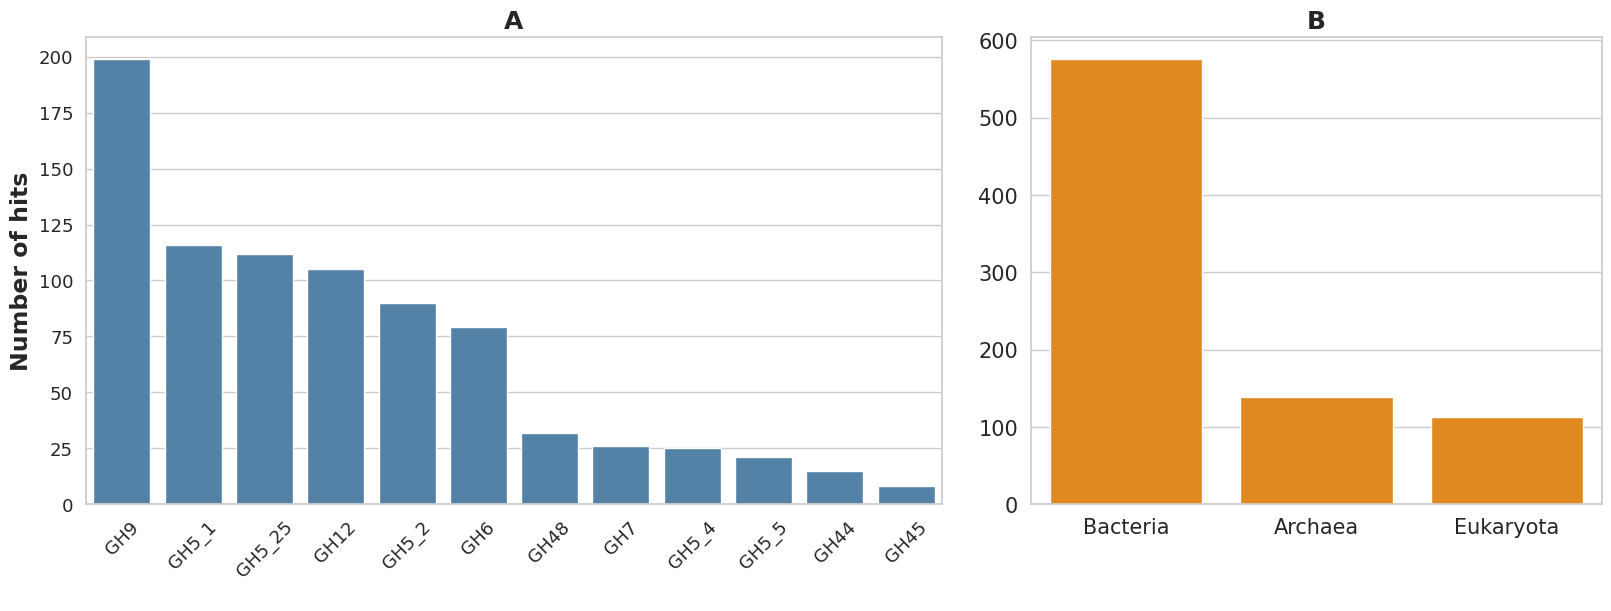

In [101]:
'''
Generate figure visualizing hmmsearch output
after implementing overlapping domain filtering
'''


sns.set_theme(style="whitegrid")

family_col = "family"
taxon_col = "domain" 

# Create figure with two axes
fig, axes = plt.subplots(1, 2, figsize=(16, 6), 
                         gridspec_kw={'width_ratios': [1.5, 1]}, 
                         constrained_layout=True)
# GH family distribution
family_counts = df[family_col].value_counts().reset_index()
family_counts.columns = [family_col, "count"]
sns.barplot(data=family_counts, x=family_col, y="count", ax=axes[0], color="steelblue")
axes[0].set_title("A", fontsize = 18, fontweight='bold')
axes[0].set_ylabel("Number of hits", fontsize = 17, fontweight='bold')
axes[0].tick_params(axis="x", rotation=45)
axes[0].tick_params(axis='both', labelsize=13)
axes[0].set_xlabel(" ")

# taxonomic group distribution
tax_counts = df[taxon_col].value_counts().head(20).reset_index()
tax_counts.columns = [taxon_col, "count"]
sns.barplot(data=tax_counts, x=taxon_col, y="count",  ax=axes[1], color="darkorange")
axes[1].set_title("B", fontsize = 18, fontweight='bold')
axes[1].set_ylabel(" ")
axes[1].tick_params(axis='both', labelsize=15)
axes[1].set_xlabel(" ")

fig.savefig("figures_tables//hits_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [102]:
# table showing top 15 organism, that had most number of hits.

df_top15 = (
    df.groupby(['taxID', 'domain'])
    .size()
    .reset_index(name='number_of_hits')
    .sort_values('number_of_hits', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

df_thermobase = pd.read_csv('data/thermobase_data/taxonkit_out.txt', sep='\t', header=None)

df_top15['taxID'] = df_top15['taxID'].astype(str).str.replace('.0', '', regex=False).str.strip()
df_thermobase['taxid'] = df_thermobase.iloc[:,1].astype(str).str.replace('.0', '', regex=False).str.strip()

df_merged = df_top15.merge(
    df_thermobase,
    left_on='taxID',
    right_on='taxid',
    how='left'
)

df_merged = df_merged.drop(columns=['taxid', 1])
last_col = df_merged.columns[-1]
df_merged.insert(0, last_col, df_merged.pop(last_col))
df_merged.rename(columns={0: "organism"}, inplace=True)

print(df_merged.to_csv(sep='\t', index=False))

df_merged.to_csv("figures_tables/top_15_organisms_in hits_list.tsv", sep='\t', index=False)

organism	taxID	domain	number_of_hits
Pseudobacteroides cellulosolvens	35825	Bacteria	59
Streptomyces bingchenggensis BCW-1	749414	Bacteria	24
Herbivorax saccincola	1677857	Bacteria	22
Thielavia terrestris	2587410	Eukaryota	21
Clostridium clariflavum EBR 45, DSM 19732	720554	Bacteria	20
Microbulbifer rhizosphaerae	1562603	Bacteria	19
Mycothermus thermophilus	85995	Eukaryota	17
Thermocatellispora tengchongensis	1073253	Bacteria	15
Remersonia thermophila	72144	Eukaryota	15
Chaetomium thermophilum	209285	Eukaryota	15
Streptomyces deccanensis	424188	Bacteria	14
Acetivibrio thermocellus	1515	Bacteria	13
Rasamsonia emersonii	68825	Eukaryota	13
Thermothelomyces thermophilus	78579	Eukaryota	13
Thermothelomyces thermophila	78579	Eukaryota	13
Herbinix luporum	1679721	Bacteria	12



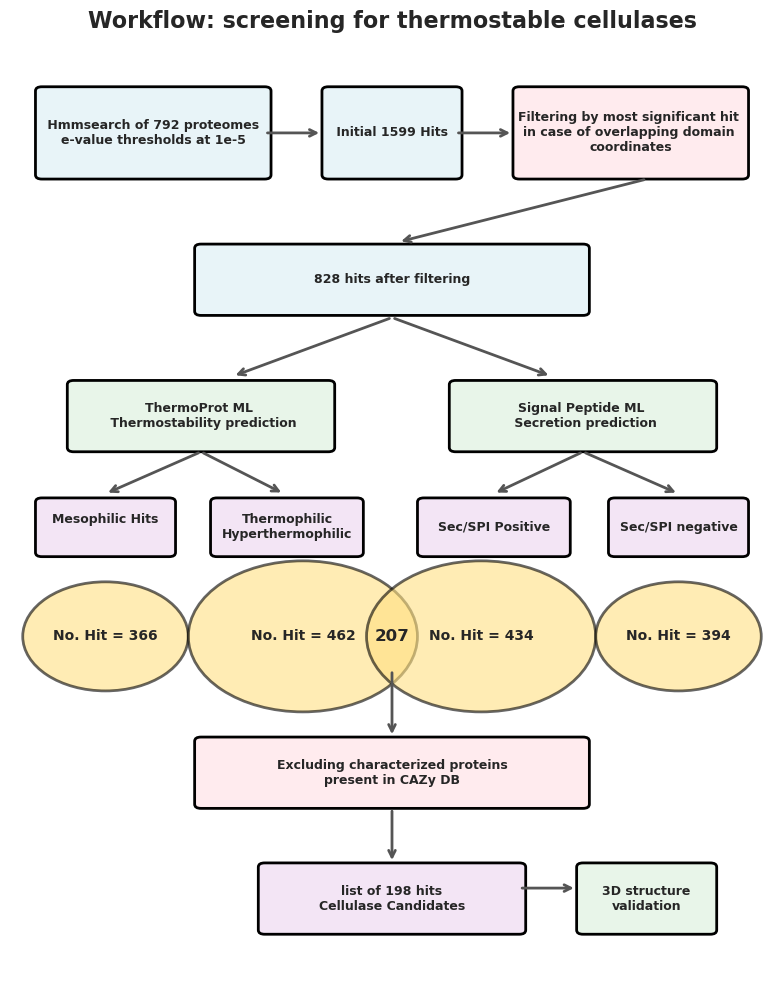

In [103]:
# Creating a flow chart


def create_project_flowchart():
    fig, ax = plt.subplots(1, 1, figsize=(8, 10))
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 22)
    ax.axis('off')
    
    # Define colors
    colors = {
        'input': '#E8F4F8',
        'filter': '#FFF3E0',
        'analysis': '#E8F5E9',
        'threshold': '#FFEBEE',
        'output': '#F3E5F5',
        'highlight': '#FFE082'
    }
    
    # Boxes: (x, y, width, height, text, color)
    boxes = [
        # Input
        (0.5, 19, 3.5, 2, " Hmmsearch of 792 proteomes \ne-value thresholds at 1e-5", colors['input']),
        (5, 19, 2, 2, " Initial 1599 Hits ", colors['input']), 
        (8, 19, 3.5, 2, "Filtering by most significant hit \nin case of overlapping domain \ncoordinates",
         colors['threshold']),
        
        # Step 1: result
        (3, 15.75, 6, 1.5, "828 hits after filtering", colors['input']),

        # ML
        (1, 12.5, 4, 1.5, "ThermoProt ML \n Thermostability prediction", colors['analysis']),
        (7, 12.5, 4, 1.5, "Signal Peptide ML \n Secretion prediction", colors['analysis']),
        
        # Header for circles
        (0.5, 10, 2, 1.2, "Mesophilic Hits\n",  colors['output']),
        (3.25, 10, 2.2, 1.2, "Thermophilic\nHyperthermophilic",  colors['output']),
        (6.5, 10, 2.2, 1.2, "Sec/SPI Positive",  colors['output']),
        (9.5, 10, 2, 1.2, "Sec/SPI negative", colors['output']),

        # Filter
        (3, 4, 6, 1.5, "Excluding characterized proteins\npresent in CAZy DB", colors['threshold']),

        #Final
        (4, 1, 4, 1.5, "list of 198 hits\nCellulase Candidates", colors['output']),

        (9, 1 ,2, 1.5, "3D structure\nvalidation", colors['analysis'])
    ]
    
    # Draw boxes
    for x, y, w, h, text, color in boxes:
        box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                             facecolor=color, edgecolor='black', linewidth=2)
        ax.add_patch(box)
        ax.text(x + w/2, y + h/2, text, ha='center', va='center', 
                fontsize=9, fontweight='bold')

    # Circles for numbers/steps
    circles = [
        (1.5, 8, 1.3, "No. Hit = 366", colors['highlight']),
        (4.6, 8, 1.8, "No. Hit = 462", colors['highlight']),
        (7.4, 8, 1.8, "No. Hit = 434", colors['highlight']),
        (10.5, 8, 1.3, "No. Hit = 394", colors['highlight'])
    ]
    
    for x, y, r, text, color in circles:
        circle = Circle((x, y), r, facecolor=color, edgecolor='black', linewidth=2, alpha=0.6)
        ax.add_patch(circle)
        ax.text(x, y, text, ha='center', va='center', fontsize=10, fontweight='bold')

        
    # Draw arrows
    arrows = [
        ((4, 20), (4.9, 20)),      # Input → Step1
        ((7, 20), (7.9, 20)),      # ste1 → filtering
        ((10, 18.9), (6.1, 17.4)), # filtering → 828
        ((6, 15.6), (8.5, 14.2)), # 828 → signalp
        ((6, 15.6), (3.5, 14.2)), # 828 → thermoprot
        ((3, 12.4), (1.5, 11.4)), # Thermophilic → Threshold
        ((3, 12.4), (4.3, 11.4)), # Thermophilic → Threshold
        ((9, 12.4), (7.6, 11.4)), # Thermophilic → Threshold
        ((9, 12.4), (10.5, 11.4)), # Thermophilic → Threshold
        ((6, 7.2), (6, 5.6)),       # Threshold → Step2
        ((6, 3.9), (6, 2.6)),
        ((8, 2),(8.9, 2))
    ]
    
    for start, end in arrows:
        ax.annotate('', xy=end, xytext=start,
                   arrowprops=dict(arrowstyle='->', lw=2, color='#555555'))


    ax.text(6, 8, '207', fontweight='bold',
        fontsize=12, ha='center', va='center')
    
    plt.suptitle('Workflow: screening for thermostable cellulases', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig('figures_tables/project_flowchart.png', dpi=300, bbox_inches='tight')
    plt.show()

create_project_flowchart()

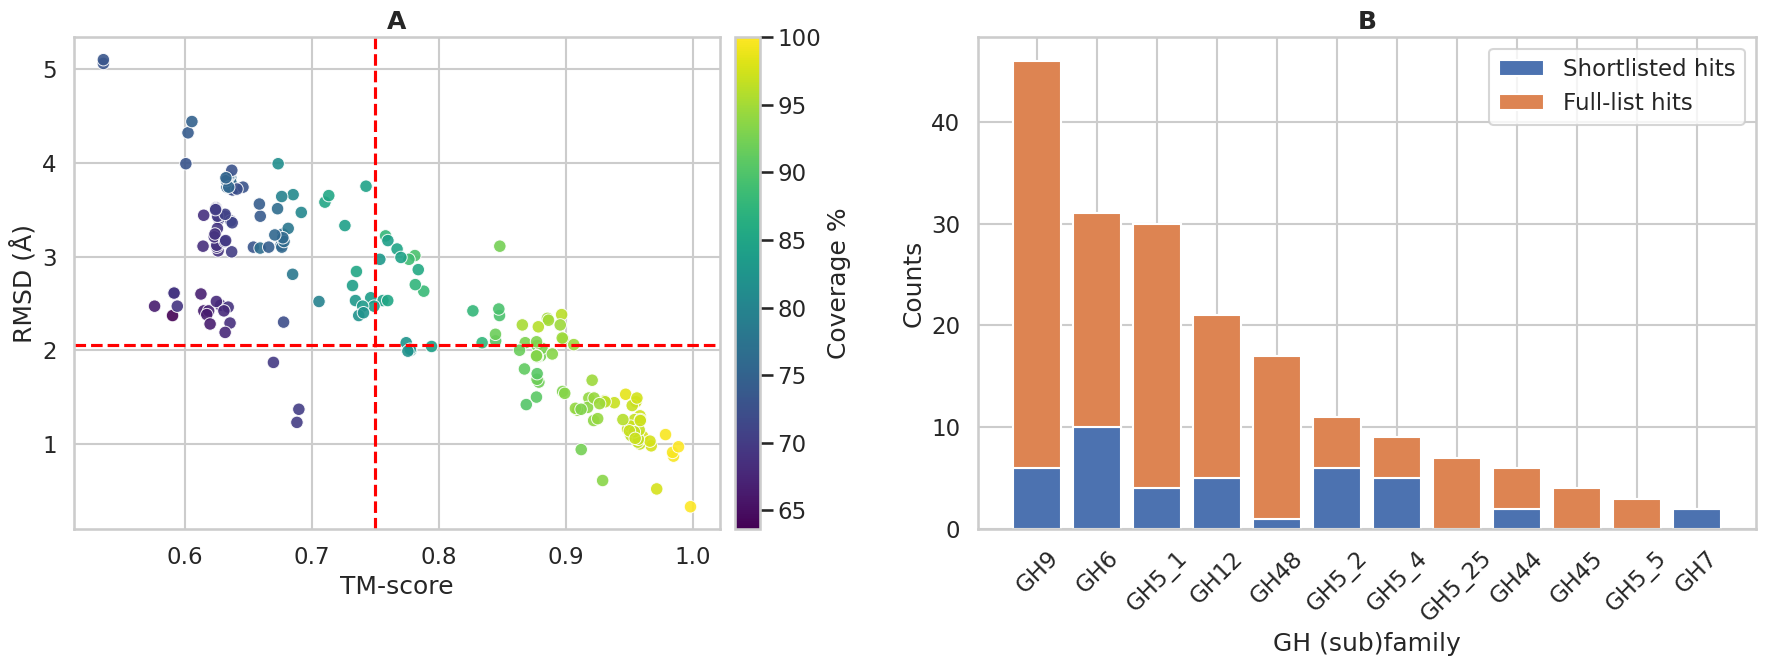

In [104]:
'''
Visualization of US-align evaluation metrics
and visualizing the thresholds introduced to shortlist the candidates
illustrating the shortlisted candidates distribution in GH families
'''


sns.set(style="whitegrid", context="talk")

INPUT = "output_files//total_hits.csv"


# Load and preprocess data
df = pd.read_csv(INPUT)

# Remove duplicate candidate–family pairs
df = df.drop_duplicates(subset=['candidate', 'family'])

tm_col = 'TM_score_ref'
rmsd_col = 'RMSD'
cov_col = 'Coverage_ref_len (%)'
family_col = 'family'

# Define shortlisted hits (same criteria you used before)
top_hits = df[
    (df[tm_col] >= 0.75) &
    (df[rmsd_col] <= 2.06) &
    (df['total_aa'] <= 800)
]

# ----------------------------------------------------------------------
# Prepare counts for stacked bar
all_counts = df[family_col].value_counts().rename('all_hits')
short_counts = top_hits[family_col].value_counts().rename('shortlisted')

counts = pd.concat([all_counts, short_counts], axis=1).fillna(0)
counts['non_shortlisted'] = counts['all_hits'] - counts['shortlisted']

# Sort families by total hits (optional, keeps bars ordered)
counts = counts.sort_values('all_hits', ascending=False)

families = counts.index
shortlisted_vals = counts['shortlisted'].values
non_shortlisted_vals = counts['non_shortlisted'].values

# ----------------------------------------------------------------------
# Create figure: A = scatter, B = stacked bar
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ----------------- Panel A: scatter all hits -------------------------
norm = mpl.colors.Normalize(vmin=df[cov_col].min(), vmax=df[cov_col].max())
cmap = sns.color_palette("viridis", as_cmap=True)

sns.scatterplot(
    data=df,
    x=tm_col,
    y=rmsd_col,
    hue=cov_col,
    hue_norm=norm,
    palette=cmap,
    legend=False,
    ax=axes[0],
    alpha=0.9
)

axes[0].axvline(0.75, color="red", linestyle="--")
axes[0].axhline(2.06, color="red", linestyle="--")
axes[0].set_xlabel("TM-score")
axes[0].set_ylabel("RMSD (Å)")
axes[0].set_title("A", fontweight='bold')

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[0], pad=0.02)
cbar.set_label("Coverage %")

# ----------------- Panel B: stacked bar per family -------------------
ax = axes[1]

ax.bar(families, shortlisted_vals, label='Shortlisted hits')
ax.bar(families, non_shortlisted_vals,
       bottom=shortlisted_vals, label='Full-list hits')

ax.set_xlabel("GH (sub)family")
ax.set_ylabel("Counts")
ax.set_title("B", fontweight = 'bold')
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.savefig("figures_tables/usalign_scatter_and_stacked_bar.png", dpi=300, bbox_inches="tight")
plt.show()

In [105]:
'''
Generating vina_output table and calculate kJ/mol
H. Bond are manually added
'''


df = pd.read_csv('output_files/vina_polar_contacts.csv')
df2 = pd.read_csv('output_files/top_hits.csv')


df_merge = pd.merge(df[['protein', 'vina_score', 'H-Bond residues', 'No. H-Bonds', 'pose']],
                    df2[['family', 'candidate', 'domain']],
                    left_on='protein',
                    right_on='candidate')

df_merge["affinity kJ/mol"] = round(df_merge['vina_score']*4.184, 3)

print(df_merge.drop(columns='candidate').to_csv(sep='\t', index=False))


df_merge.drop(columns='candidate').to_csv("figures_tables/Final_candidate_list_hydrogen_bonds.tsv", sep='\t', index=False)

protein	vina_score	H-Bond residues	No. H-Bonds	pose	family	domain	affinity kJ/mol
A0A1C6VT57	-9.918	SER262, SER266, ASP307, ASN315, HIS360	5	2	GH6	Bacteria	-41.497
GAA4135145.1	-9.764	SER236, SER240, ASP281, ASN289, HIS334, ASN343, ASN373, SER546	8	1	GH6	Bacteria	-40.853
D6Y5G2	-9.71	TYR274, ASN337, HIS378, ASN387, ASN418, ASP549	6	1	GH6	Bacteria	-40.627
KAL2119084.1	-9.125	ARG448, ASN482, LYS486, ASP520, ASP540, SER716	6	1	GH7	Eukaryota	-38.179
D6Y2K0	-9.046	SER204, GLU205, GLN329, ASP377, TYR477	5	6	GH48	Bacteria	-37.848
G2QW39	-9.042	ASP257, ASN265, HIS302, ASN341, LYS430, GLU434	6	4	GH6	Eukaryota	-37.832
A0A840P6F7	-8.907	SER456, ASP499, ASN507, HIS547, ASN587, TRP685, LYS712, SER760	8	1	GH6	Bacteria	-37.267
A0A0F4YZV4	-8.789	ASP149, TYR183, ARG188, ASN243, HIS280, ASN319, LYS408	7	4	GH6	Eukaryota	-36.773
GCE50103.1	-8.78	SER291, ASP334, ASN342, HIS382, GLN583	5	2	GH6	Bacteria	-36.736
G0SD43	-8.695	ASP252, THR259, ASN260, HIS297, LYS425	5	4	GH6	Eukaryota	-36.38
A0A3D9V8T3	-8.444	TY

In [106]:
# Reading in EpHod output

df = pd.read_csv('output_files/opt_ph_prediction.csv')
df = df.round(2)
df = df.rename(columns={'Unnamed: 0': 'candidate'})
df2 = pd.read_csv('output_files/top_hits.csv')
print(df.describe().round(3).to_csv(sep='\t'))


# Print EpHod summary data
df.describe().round(3).to_csv("figures_tables/ephod_prediction_summar.tsv", sep='\t')


# Merge EpHod and hits table to use the clean protein naming
merged = pd.merge(
    df2[['accession', 'candidate']],
    df[['candidate', 'RLATtr', 'SVR', 'Ensemble']],
    left_on='accession',
    right_on='candidate')
df = merged.drop(columns=['candidate_y', 'accession']).rename(columns={'candidate_x': 'candidate'})

	RLATtr	SVR	Ensemble
count	39.0	39.0	39.0
mean	6.419	5.866	6.141
std	0.786	0.791	0.729
min	3.8	2.89	3.34
25%	6.135	5.795	5.97
50%	6.35	6.12	6.22
75%	6.875	6.23	6.545
max	7.75	7.03	7.19



/tmp/ipykernel_3203935/4028003685.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


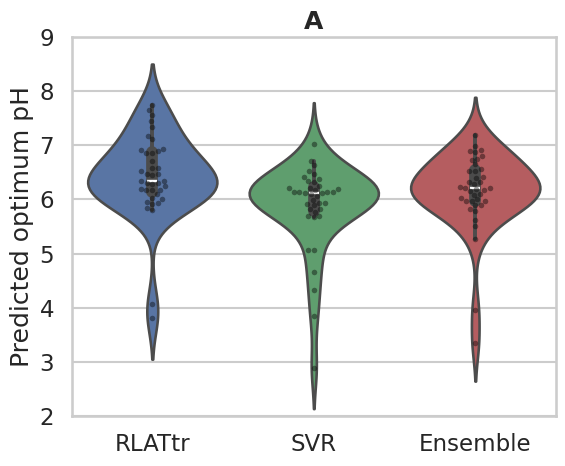

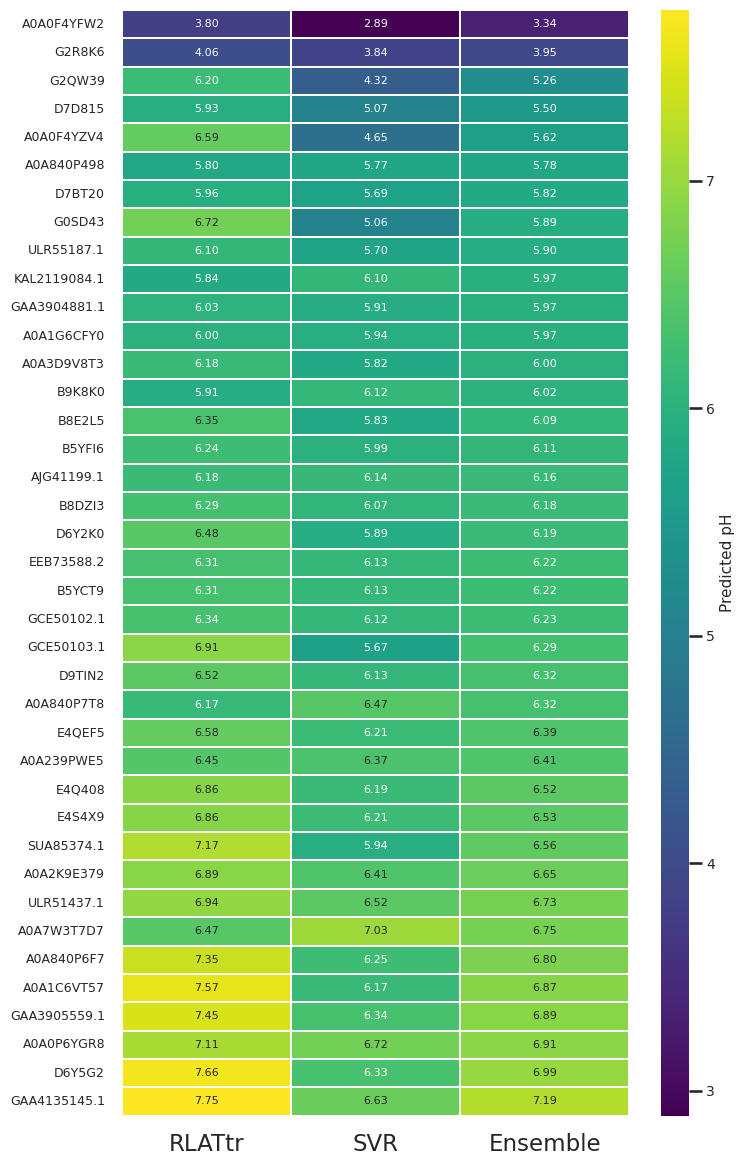

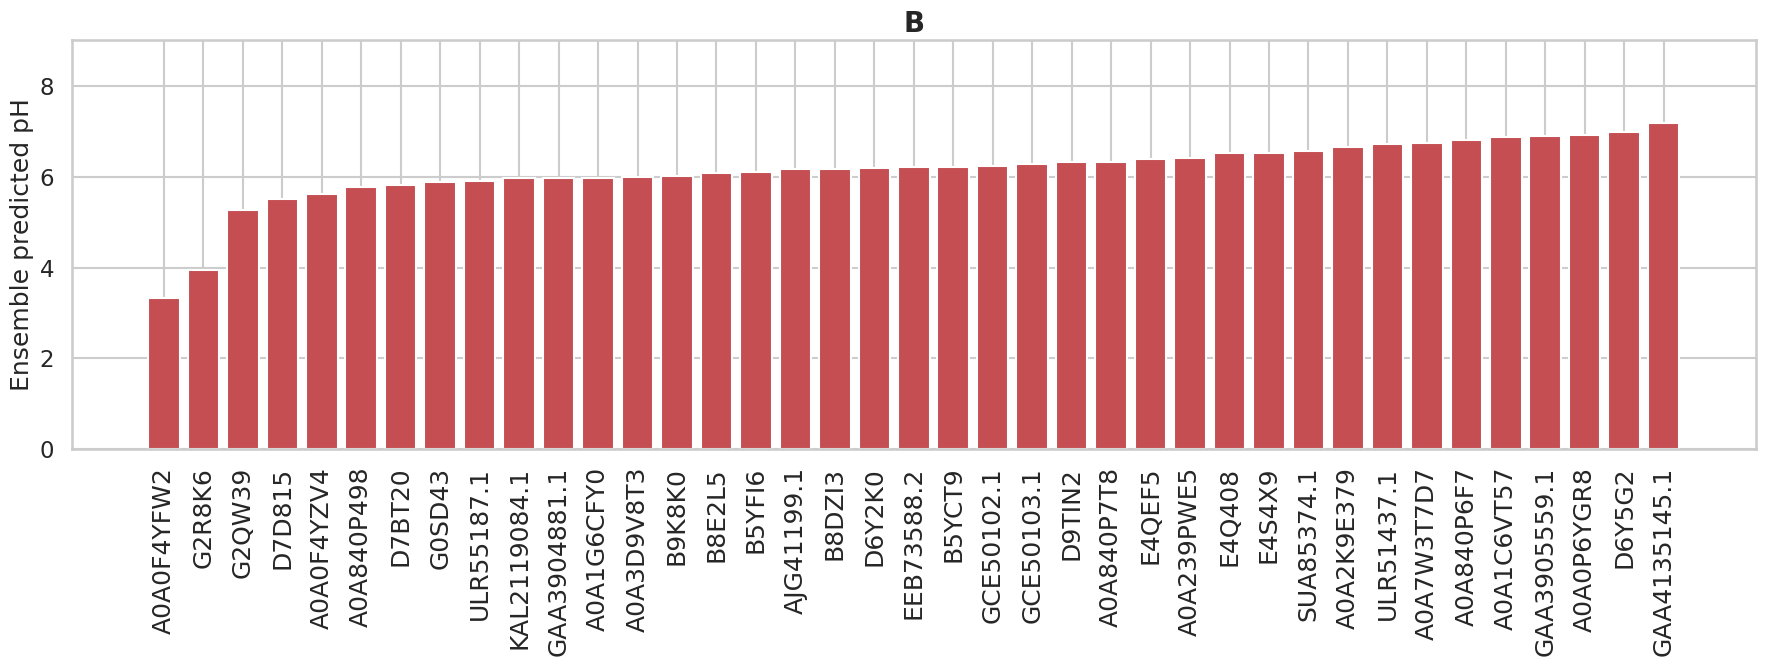

In [107]:
# Preparing data for Visualizing EpHod output

cols = ['RLATtr', 'SVR', 'Ensemble']
plot_df = df.copy()
plot_df[cols] = plot_df[cols].apply(pd.to_numeric, errors='coerce')
plot_df = plot_df.dropna(subset=cols)

if 'candidate' not in plot_df.columns:
    raise KeyError("Column 'candidate' not found. Rename your ID column to 'candidate' or edit the script.")

long_df = plot_df.melt(
    id_vars='candidate',
    value_vars=cols,
    var_name='Model',
    value_name='Predicted_pH'
)

order = plot_df.sort_values('Ensemble')['candidate'].tolist()
heat = plot_df.set_index('candidate')[cols].loc[order]
ranked = plot_df[['candidate', 'Ensemble']].sort_values('Ensemble', ascending=True)

sns.set_theme(style='whitegrid', context='talk')
palette = {'RLATtr': '#4C72B0', 'SVR': '#55A868', 'Ensemble': '#C44E52'}


# =========================
# Figure 1: boxplot only
fig1, ax1 = plt.subplots(figsize=(6, 5))
sns.violinplot(
    data=long_df,
    x='Model',
    y='Predicted_pH',
    palette=palette,
    ax=ax1
)
sns.swarmplot(
    data=long_df,
    x='Model',
    y='Predicted_pH',
    color='black',
    size=4,
    alpha=0.4,
    ax=ax1
)
ax1.set_title('A', fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Predicted optimum pH')
ax1.set_ylim(2, 9)

fig1.tight_layout()
fig1.savefig('figures_tables/ephod_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()


# =========================
# Figure 2: heatmap 
fig2, ax2 = plt.subplots(figsize=(8, 12))
hm = sns.heatmap(
    heat,
    cmap='viridis',
    annot=True,
    fmt='.2f',
    linewidths=0.005,
    cbar=True,
    cbar_kws={'label': 'Predicted pH',  'aspect': 40},
    annot_kws={'size': 8},
    ax=ax2
)

ax2.set_ylabel('')
ax2.tick_params(axis='y', labelsize=9)

cbar_heat = hm.collections[0].colorbar
cbar_heat.ax.tick_params(labelsize=10)
cbar_heat.set_label('Predicted pH', fontsize=11)

fig2.tight_layout()
fig2.savefig('figures_tables/supplementary_data/ephod_heatmap.png', dpi=300, bbox_inches='tight')
#plt.show()

# =========================
# Figure 3: ranked bar plot only
fig3, ax3 = plt.subplots(figsize=(18, 7))
ax3.bar(ranked['candidate'], ranked['Ensemble'], color=palette['Ensemble'])
ax3.set_title('B', fontweight='bold', fontsize=20)
ax3.set_ylabel('Ensemble predicted pH')
ax3.tick_params(axis='x', rotation=90, labelsize=18)
ax3.set_ylim(0, 9)

fig3.tight_layout()
fig3.savefig('figures_tables/ephod_ranked_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [108]:
#Generate Table combining EpHod results with calculated Isoelectric points 

df = pd.read_csv("output_files/ph_pi_summary.csv")

df.drop(columns="accession").to_csv("figures_tables/opt_pH_pI.tsv", sep='\t', index = False)
print(df.drop(columns="accession").to_csv(sep='\t', index = False))

candidate	family	pI	Ensemble	SVR	RLATtr	molecular_weight	length
GAA4135145.1	GH6	4.8	7.19	6.63	7.75	60473.93	566
A0A7W3T7D7	GH5_4	4.87	6.75	7.03	6.47	63616.2	579
ULR51437.1	GH5_1	5.55	6.73	6.52	6.94	55578.04	526
ULR55187.1	GH9	5.67	5.9	5.7	6.1	80427.53	747
B9K8K0	GH12	4.57	6.02	6.12	5.91	31751.63	274
SUA85374.1	GH6	4.73	6.56	5.94	7.17	76171.42	716
A0A3D9V8T3	GH9	6.29	6.0	5.82	6.18	68840.64	635
E4QEF5	GH5_2	5.35	6.39	6.21	6.58	85121.16	755
D7D815	GH5_1	7.66	5.5	5.07	5.93	52573.15	453
A0A1G6CFY0	GH5_2	9.85	5.97	5.94	6.0	37738.46	340
D7BT20	GH9	5.97	5.82	5.69	5.96	64003.31	610
A0A840P498	GH9	5.86	5.78	5.77	5.8	81319.83	750
A0A840P6F7	GH6	4.66	6.8	6.25	7.35	81306.11	780
A0A840P7T8	GH5_2	5.92	6.32	6.47	6.17	48328.69	448
A0A0F4YFW2	GH5_4	4.58	3.34	2.89	3.8	67909.76	632
A0A0F4YZV4	GH6	4.29	5.62	4.65	6.59	48448.17	459
D9TIN2	GH5_2	8.92	6.32	6.13	6.52	64477.23	568
GAA3904881.1	GH9	5.93	5.97	5.91	6.03	82221.47	767
GAA3905559.1	GH6	6.04	6.89	6.34	7.45	61177.31	586
E4Q408	GH5_2	5.4	6.52	6.19	6.86	

In [109]:
# Generating table with reference structures used for US-align 



BASE_DIR = Path("data/reference_structures/")


def extract_pdb_id(name):
    m = re.search(r'([0-9][A-Za-z0-9]{3})', name)
    return m.group(1).lower() if m else None

def extract_local_title(pdb_path):
    title_lines = []
    with open(pdb_path, "r", errors="ignore") as f:
        for line in f:
            if line.startswith("TITLE"):
                title_lines.append(line[10:].strip())
    return " ".join(title_lines).strip() if title_lines else pdb_path.stem

def fetch_pdb_metadata(pdb_id):
    url = f"https://data.rcsb.org/rest/v1/core/entry/{pdb_id}"
    r = requests.get(url, timeout=20)
    if r.status_code != 200:
        return None

    data = r.json()

    protein_name = data.get("struct", {}).get("title")
    structure_doi = f"https://doi.org/10.2210/pdb{pdb_id}/pdb"

    primary = data.get("rcsb_primary_citation", {})
    publication_doi = primary.get("pdbx_database_id_DOI") or primary.get("doi")

    if publication_doi and not str(publication_doi).startswith("http"):
        publication_doi = f"https://doi.org/{publication_doi}"

    return {
        "protein_name": protein_name,
        "structure_doi": structure_doi,
        "publication_doi": publication_doi
    }

rows = []

for family_dir in sorted(BASE_DIR.iterdir()):
    if not family_dir.is_dir():
        continue

    gh_family = family_dir.name

    for pdb_file in sorted(family_dir.glob("*.pdb")):
        pdb_id = extract_pdb_id(pdb_file.stem)

        protein_name = None
        structure_doi = None
        publication_doi = None

        if pdb_id:
            meta = fetch_pdb_metadata(pdb_id)
            if meta:
                protein_name = meta.get("protein_name")
                structure_doi = meta.get("structure_doi")
                publication_doi = meta.get("publication_doi")

        if not protein_name:
            protein_name = extract_local_title(pdb_file)

        rows.append({
            "reference structure (PDB ID)": pdb_file.name.split('_')[-1].replace(".pdb", ""),
            "protein name": protein_name,
            "GH (sub)family": gh_family,
            "structure_doi": structure_doi,
            "publication_doi": publication_doi
        })

df = pd.DataFrame(rows, columns=[
    "reference structure (PDB ID)",
    "protein name",
    "GH (sub)family",
    "structure_doi",
    "publication_doi"
])


In [110]:
# table showing the reference structures used in structural alignment
print(df.to_csv(sep='\t', index=False))

reference structure (PDB ID)	protein name	GH (sub)family	structure_doi	publication_doi
3VGI	The crystal structure of hyperthermophilic family 12 endocellulase from Pyrococcus furiosus	gh12	https://doi.org/10.2210/pdb3vgi/pdb	https://doi.org/10.1016/j.febslet.2012.02.029
2E4T	Crystal structure of Cel44A, GH family 44 endoglucanase from Clostridium thermocellum	gh44	https://doi.org/10.2210/pdb2e4t/pdb	https://doi.org/10.1074/jbc.M706835200
5XBU	Crystal structure of GH45 endoglucanase EG27II in apo-form	gh45	https://doi.org/10.2210/pdb5xbu/pdb	https://doi.org/10.1107/S2059798319003000
5YJ6	The exoglucanase CelS from Clostridium thermocellum	gh48	https://doi.org/10.2210/pdb5yj6/pdb	https://doi.org/10.1186/s13068-017-1009-4
2ZUM	Functional Analysis of Hyperthermophilic Endocellulase from the Archaeon Pyrococcus horikoshii	gh5_1	https://doi.org/10.2210/pdb2zum/pdb	https://doi.org/10.1002/prot.22602
2CKS	X-RAY CRYSTAL STRUCTURE OF THE CATALYTIC DOMAIN OF THERMOBIFIDA FUSCA ENDOGLUCANASE CEL5A